In [1]:
%pwd

'd:\\Tipto\\OmniChef-Nexus\\notebooks'

In [2]:
import os 
os.chdir("../")

In [3]:
import os
os.environ["HF_DATASETS_CACHE"] = "D:/hf_cache"

In [4]:
# load the dataset from hf
from datasets import load_dataset
dataset = load_dataset(
    "tiptoghosh/food-recipes-15k",
    split = "train"
)

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/27 [00:00<?, ?it/s]

In [5]:
# load safe tensors
from safetensors.torch import load_file
file_path = "data/embedding_tensors/all_recipes_image_text_embeddings.safetensors"
recipe_image_text_embeddings_15k = load_file(file_path)["image_text_embeddings"]
recipe_image_text_embeddings_15k

tensor([[-0.9507,  1.1211,  2.6562,  ..., -2.3281, -0.3948,  0.0395],
        [-1.1504,  0.4902,  2.0195,  ...,  0.7817, -1.3008,  0.6104],
        [-0.1017, -1.1660,  0.9277,  ..., -1.5869, -2.0918, -0.8267],
        ...,
        [-0.7588,  1.2119,  1.5850,  ...,  0.6348, -1.9834, -0.1635],
        [-0.5239, -0.4646, -0.3879,  ..., -0.8237, -1.7998,  0.6162],
        [ 0.2712, -0.6646,  1.5234,  ..., -0.1637, -1.3701, -1.0488]],
       dtype=torch.float16)

In [6]:
recipe_image_text_embeddings_15k.shape

torch.Size([15698, 2048])

# Qdrant setup

In [7]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, OptimizersConfigDiff, HnswConfigDiff

In [8]:
QDRANT_HOST = "localhost"
QDRANT_PORT = 6333
VECTOR_DIM = 2048
DISTANCE = Distance.COSINE

In [9]:
COLLECTIONS = {
    "image_text_index":   "image+text  embeddings",
    "image_index": "image-only embeddings",
    "text_index": "text embeddings"
}

In [10]:
client = QdrantClient(host = QDRANT_HOST, port = QDRANT_PORT)

In [12]:
for col_name , description in COLLECTIONS.items():
    existing = [c.name for c in client.get_collections().collections]
    
    if col_name in existing:
       print(f"[SKIP] '{col_name}' already exists — delete it first if you want a fresh start.")
       continue
    
    client.create_collection(
        collection_name = col_name,
        vectors_config = VectorParams(
            size = VECTOR_DIM,
            distance = DISTANCE,
            on_disk = False, # keep in ram for fast query
        ),
        hnsw_config=HnswConfigDiff(
            m = 16,
            ef_construct = 200,
            full_scan_threshold = 10_000,
        ),
        optimizers_config = OptimizersConfigDiff(
            indexing_threshold = 20_000,   
        ),
    )
    print(f"[CREATED] '{col_name}' -> {description}")

[SKIP] 'image_text_index' already exists — delete it first if you want a fresh start.
[SKIP] 'image_index' already exists — delete it first if you want a fresh start.
[SKIP] 'text_index' already exists — delete it first if you want a fresh start.


In [13]:
for col in client.get_collections().collections:
    info = client.get_collection(col.name)
    print(f"  {col.name:20s}  dim={info.config.params.vectors.size}  "
          f"distance={info.config.params.vectors.distance}  "
          f"points={info.points_count}")

  image_index           dim=2048  distance=Cosine  points=0
  image_text_index      dim=2048  distance=Cosine  points=0
  text_index            dim=2048  distance=Cosine  points=0


### Build the metadata

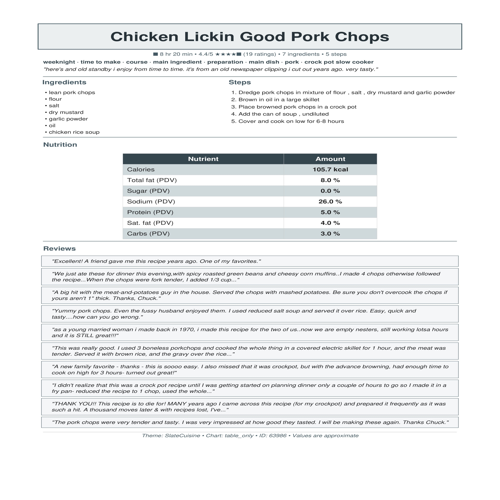

In [14]:
dataset[0]['image'].resize((500 , 500))

In [15]:
dataset

Dataset({
    features: ['name', 'recipe_id', 'minutes', 'description', 'tags', 'steps', 'n_steps', 'n_ingredients', 'nutrition', 'rating', 'num_ratings', 'markdown', 'image'],
    num_rows: 15698
})

In [16]:
recipe_image_text_embeddings_15k.shape

torch.Size([15698, 2048])

In [20]:
type(dataset[0]['image'])

PIL.JpegImagePlugin.JpegImageFile

### Image Handling
---
we will convert a PIL image(from dataset) into a base64-encoded JPEG string sized for 
direct injection into the generation model(vision-language model).

In [17]:
import io
import base64
from PIL import Image

In [18]:
MAX_SIZE = 512
JPEG_QUALITY = 85

In [21]:
def pil_to_base64(image: Image.Image) -> str | None:
    """Resize PIL image and return as base64 JPEG string.

    Args:
        image (Image.Image): PIL image

    Returns:
        str | None: return the JPEG string, on fail returns None
    """
    if image is None:
        return None 
    
    try:
        if image.mode != "RGB":
            image = image.convert("RGB")
        
        w, h = image.size
        scale = MAX_SIZE / max(w , h)
        if scale < 1.0: # only downscale
            new_w , new_h = int(w * scale) , int(h * scale)
            image = image.resize((new_w, new_h), Image.LANCZOS)
            
        buf =  io.BytesIO()  
        image.save(buf, format="JPEG", quality=JPEG_QUALITY, optimize=True)
        return base64.b64encode(buf.getvalue()).decode("utf-8")
    
    except Exception as e:
        print(f"[WARN] image conversion failed: {e}")
        return None 

In [22]:
test = pil_to_base64(dataset[0]['image'])
test

'...'

In [24]:
def base64_to_pil(b64_str: str) -> Image.Image | None:
    """Reverse helper — useful for debugging / spot-checking stored images."""
    if not b64_str:
        return None
    try:
        return Image.open(io.BytesIO(base64.b64decode(b64_str)))
    except Exception:
        return None

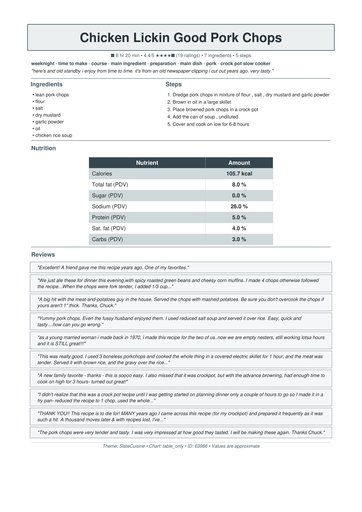

In [25]:
base64_to_pil(test)

In [26]:
import os
import json
import torch
import numpy as np
from safetensors.torch import load_file
from datasets import load_dataset
from qdrant_client import QdrantClient
from qdrant_client.models import PointStruct, UpdateStatus
from tqdm import tqdm

In [37]:
SAFETENSORS_PATH = "data/embedding_tensors/all_recipes_image_text_embeddings.safetensors"
EMBEDDING_KEY = "image_text_embeddings"
HF_DATASET_ID = "tiptoghosh/food-recipes-15k"
COLLECTION_NAME = "image_text_index"
CHECKPOINT_PATH = "data/upsert_checkpoint.json"

QDRANT_HOST = "localhost"
QDRANT_PORT = 6333
BATCH_SIZE = 64       
TOTAL_ROWS = dataset.shape[0]

In [31]:
def load_checkpoint() -> int:
    """Returns the last successfully upserted index (exclusive). 0 = fresh start."""
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH) as f:
            data = json.load(f)
        idx = data.get("last_upserted_index", -1)
        print(f"[RESUME]  Checkpoint found — resuming from index {idx + 1}")
        return idx + 1
    return 0

In [32]:
def save_checkpoint(last_index: int):
    os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
    with open(CHECKPOINT_PATH, "w") as f:
        json.dump({"last_upserted_index": last_index}, f)

In [33]:
def validate_embedding(vec: np.ndarray, idx: int) -> bool:
    """Skip NaN/Inf rows — shouldn't happen but guards against corrupt tensors."""
    if np.isnan(vec).any() or np.isinf(vec).any():
        print(f"  [WARN] Skipping index {idx} — NaN/Inf in embedding")
        return False
    return True

In [35]:
print("Loading safetensors embeddings...")
tensors = load_file(SAFETENSORS_PATH)
embeddings = tensors[EMBEDDING_KEY] 
embeddings_np = embeddings.to(torch.float32).numpy()   # (15698, 2048) float32
print(f"  Shape : {embeddings_np.shape}")
print(f"  Dtype : {embeddings_np.dtype}")
print(f"  Memory: {embeddings_np.nbytes / 1024**2:.1f} MB")

Loading safetensors embeddings...
  Shape : (15698, 2048)
  Dtype : float32
  Memory: 122.6 MB


In [38]:
client = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)
col_info = client.get_collection(COLLECTION_NAME)
print(f"\nQdrant '{COLLECTION_NAME}' — current points: {col_info.points_count}")


Qdrant 'image_text_index' — current points: 0


In [39]:
start_index = load_checkpoint()
start_index

0

In [40]:
# make a validation check for further run
if start_index >= TOTAL_ROWS:
    print("All rows already upserted.")
    exit(0)

In [43]:
# main upsert loop starts from here
batch = []
last_upserted = start_index - 1
skipped = 0
failed_images = 0

pbar = tqdm(
    total = TOTAL_ROWS - start_index,
    desc = "Upserting",
    unit = "recipe",
    dynamic_ncols = True
)

for global_index , row in enumerate(dataset):
    # skip already upserted rows
    if global_index < start_index:
        continue
    
    vec = embeddings_np[global_index]
    
    if not validate_embedding(vec , global_index):
        skipped += 1
        pbar.update(1)
        continue
    
    # get the markdown recipe
    markdown_text = row.get("markdown") or ""
    raw_image = row.get("image")
    image_b64 = pil_to_base64(raw_image)
    if image_b64 is None:
        failed_images += 1
    
    payload = {
        "markdown": markdown_text,
        "image": image_b64
    }
    
    batch.append(PointStruct(
        id = global_index, vector = vec.tolist(), payload = payload
    ))
    
    if len(batch) == BATCH_SIZE:
        result = client.upsert(
            collection_name = COLLECTION_NAME,
            points = batch,
            wait = True
        )
        assert result.status == UpdateStatus.COMPLETED, f"Upsert failed at batch ending index {global_index}"
        last_upserted = global_index
        save_checkpoint(last_upserted)
        batch.clear()

# last remain points
if batch:
    result = client.upsert(
        collection_name = COLLECTION_NAME,
        points = batch,
        wait = True
    )
    assert result.status == UpdateStatus.COMPLETED, f"Upsert failed at batch ending index {global_index}"
    last_upserted = global_index
    save_checkpoint(last_upserted)
    batch.clear()

pbar.close()
print("\nTriggering HNSW index optimisation...")
client.update_collection(
    collection_name = COLLECTION_NAME,
    optimizer_config = {"indexing_threshold": 0},   
)
print("Index build queued (runs in background — check verify_qdrant for status)")

Upserting:   0%|          | 0/15698 [19:27<?, ?recipe/s]


Triggering HNSW index optimisation...
Index build queued (runs in background — check verify_qdrant for status)


In [44]:
import torch
from transformers import AutoModel , AutoProcessor
from transformers.image_utils import load_image
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [45]:
# load the embedding model with a specific revision version
model_name = "nvidia/llama-nemotron-embed-vl-1b-v2"
revision = "062ffaa1e3d24a8a50bd6a7ac7b8e54103e1f01d"

embedding_model = AutoModel.from_pretrained(
    model_name,
    revision = revision,
    dtype = torch.float16,
    trust_remote_code = True,
    attn_implementation = "flash_attention_2",
    device_map = "auto"
).eval()

config.json: 0.00B [00:00, ?B/s]

configuration_llama_nemotron_vl.py: 0.00B [00:00, ?B/s]

modeling_llama_nemotron_vl.py: 0.00B [00:00, ?B/s]

processing_llama_nemotron_vl.py: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.36G [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2:
- processing_llama_nemotron_vl.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/600 [00:00<?, ?it/s]

In [46]:
# make a helper function to change the model's modality
def prepare_processor(modality , embedding_model):
    """Prepare the model for different modality.

    Args:
        modality (str): can be 'text' , 'image' or 'image_text'
        embedding_model (_type_): embedding model

    Returns:
        _type_: (modality , embedding_model)
    """
    # Set max number of tokens (p_max_length) based on modality
    if modality == "image":
        p_max_length = 2048
    elif modality == "image_text":
        p_max_length = 10240
    elif modality == "text":
        p_max_length = 8192
    embedding_model.processor.p_max_length = p_max_length
    # Image specific settings(only matter if image is present)
    # Sets max number of tiles an image can be split. Each tile consumes 256 tokens.
    embedding_model.processor.max_input_tiles = 6
    # Enables an extra tile with the full image at lower resolution
    embedding_model.processor.use_thumbnail = True
    return modality , embedding_model

In [48]:
from qdrant_client import QdrantClient

qdrant = QdrantClient(host = QDRANT_HOST , port = QDRANT_PORT)
info = qdrant.get_collection(COLLECTION_NAME)
print(f"Collection: {COLLECTION_NAME}")
print(f"Points: {info.points_count}")
print(f"Dimension: {info.config.params.vectors.size}")

Collection: image_text_index
Points: 15698
Dimension: 2048


In [50]:
def _l2_normalize(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x)
    return x / (x.norm(p=2, dim=-1, keepdim=True) + eps)

In [69]:
import warnings
warnings.filterwarnings("ignore")

In [70]:
text_query = "spicy chicken recipe"
modality, embedding_model = prepare_processor(
    modality = "text",
    embedding_model = embedding_model
)

In [71]:
with torch.inference_mode():
    query_embedding = embedding_model.encode_queries([text_query])

query_embedding.shape

torch.Size([1, 2048])

In [74]:
query_vec = _l2_normalize(query_embedding).squeeze(0).float().tolist()
len(query_vec)

2048

In [75]:
hits = qdrant.query_points(
    collection_name = COLLECTION_NAME,
    query = query_vec,
    limit = 3,
    with_payload = True,
)
hits

QueryResponse(points=[ScoredPoint(id=13451, version=211, score=0.50365543, payload={'markdown': '# Spicy Indian Grilled Chicken\n**Recipe ID:** 123287\n**Cook Time:** 15 minutes\n**Rating:** 4.37/5 stars (19 reviews)\n\n## Description\ncontrary to many indian dishes, this comes together quickly. great on the grill for a change.\n\n## Ingredients\nblack pepper, paprika, cayenne pepper, garam masala, ground cumin, oregano, salt, garlic clove, vegetable oil, lemon juice, plain yogurt, chicken pieces\n\n## Instructions\n1. Combine all marinade ingredients well\n2. Coat chicken pieces in marinade paste\n3. Marinate from 1 hour , or up to overnight in the refrigerator\n4. Grill over medium coals until browned , about 15 minutes each side\n\n## Nutrition (PDV)\nCalories: 556.9, Total Fat: 64.0, Sugar: 3.0, Sodium: 36.0, Protein: 78.0, Saturated Fat: 52.0\n\n## Reviews\n- This was some truly tasty chicken. I followed the recipe exactly except I was a little short on the tbsp of papricka. Grill

In [89]:
extracted_data = []
for rank , hit in enumerate(hits):
    hit_obj = hit[1][0]
    extracted_data.append({
        "rank": rank, 
        "id": hit_obj.id,
        "score": hit_obj.score,
        "payload": hit_obj.payload
    })

In [92]:
extracted_data[0]['payload']['markdown']

'# Spicy Indian Grilled Chicken\n**Recipe ID:** 123287\n**Cook Time:** 15 minutes\n**Rating:** 4.37/5 stars (19 reviews)\n\n## Description\ncontrary to many indian dishes, this comes together quickly. great on the grill for a change.\n\n## Ingredients\nblack pepper, paprika, cayenne pepper, garam masala, ground cumin, oregano, salt, garlic clove, vegetable oil, lemon juice, plain yogurt, chicken pieces\n\n## Instructions\n1. Combine all marinade ingredients well\n2. Coat chicken pieces in marinade paste\n3. Marinate from 1 hour , or up to overnight in the refrigerator\n4. Grill over medium coals until browned , about 15 minutes each side\n\n## Nutrition (PDV)\nCalories: 556.9, Total Fat: 64.0, Sugar: 3.0, Sodium: 36.0, Protein: 78.0, Saturated Fat: 52.0\n\n## Reviews\n- This was some truly tasty chicken. I followed the recipe exactly except I was a little short on the tbsp of papricka. Grilled up nicely. We really enjoyed our supper that night, but the chicken, cold, the next day, was 

In [102]:
results = []
for rank, hit in enumerate(hits.points):
    # hit_obj = hit[1][0]
    payload = hit.payload or {}
    b64_img = payload.get("image")

    # decode base64 to PIL image
    pil_img = None
    if b64_img:
        try:
            import io, base64
            pil_img = Image.open(io.BytesIO(base64.b64decode(b64_img)))
        except Exception:
            pass

    results.append({
        "rank" : rank,
        "index" : hit_obj.id,
        "score" : round(hit.score, 4),
        "markdown": payload.get("markdown", ""),
        "image" : pil_img,
    })

In [103]:
results

[{'rank': 0,
  'index': 13451,
  'score': 0.5037,
  'markdown': '# Spicy Indian Grilled Chicken\n**Recipe ID:** 123287\n**Cook Time:** 15 minutes\n**Rating:** 4.37/5 stars (19 reviews)\n\n## Description\ncontrary to many indian dishes, this comes together quickly. great on the grill for a change.\n\n## Ingredients\nblack pepper, paprika, cayenne pepper, garam masala, ground cumin, oregano, salt, garlic clove, vegetable oil, lemon juice, plain yogurt, chicken pieces\n\n## Instructions\n1. Combine all marinade ingredients well\n2. Coat chicken pieces in marinade paste\n3. Marinate from 1 hour , or up to overnight in the refrigerator\n4. Grill over medium coals until browned , about 15 minutes each side\n\n## Nutrition (PDV)\nCalories: 556.9, Total Fat: 64.0, Sugar: 3.0, Sodium: 36.0, Protein: 78.0, Saturated Fat: 52.0\n\n## Reviews\n- This was some truly tasty chicken. I followed the recipe exactly except I was a little short on the tbsp of papricka. Grilled up nicely. We really enjoyed 

In [104]:
len(results)

3

In [105]:
def query_qdrant(text_query: str = None, image_query: Image.Image = None, top_k: int = 5) -> list[dict]:
    """
    Encodes the query using the already-loaded embedding_model,
    searches Qdrant, and returns top_k results with full payload.

    Each result dict:
        rank, score, index, name, markdown, image (PIL)
    """
    global embedding_model
    # 1. identify modality
    if text_query and image_query:
        modality = "image_text"
    elif text_query:
        modality = "text"
    elif image_query:
        modality = "image"
    else:
        raise ValueError("Provide at least one of text_query or image_query.")

    # 2. prepare processor and encode 
    modality, embedding_model = prepare_processor(
        modality = modality,
        embedding_model = embedding_model
    )

    with torch.inference_mode():
        if modality == "text":
            query_embedding = embedding_model.encode_queries([text_query])
        elif modality == "image":
            query_embedding = embedding_model.encode_documents(images=[image_query])
        elif modality == "image_text":
            query_embedding = embedding_model.encode_documents(
                texts = [text_query], images = [image_query]
            )

    # to normalised float32 list (Qdrant expects list[float])
    if not isinstance(query_embedding, torch.Tensor):
        query_embedding = torch.tensor(query_embedding)

    query_vec = _l2_normalize(query_embedding).squeeze(0).float().tolist()

    # 4. search Qdrant
    hits = qdrant.query_points(
        collection_name = COLLECTION_NAME,
        query = query_vec,
        limit = top_k,
        with_payload = True,
    )

    # 5. parse results
    results = []
    # Loop over hits.points to successfully access the clean ScoredPoint objects
    for rank, hit in enumerate(hits.points, 1):
        payload  = hit.payload or {}
        b64_img  = payload.get("image")

        # decode base64 to PIL image
        pil_img = None
        if b64_img:
            try:
                pil_img = Image.open(io.BytesIO(base64.b64decode(b64_img)))
            except Exception:
                pass

        results.append({
            "rank" : rank,
            "index" : hit.id,
            "score" : round(hit.score, 4),
            "name" : payload.get("name", ""), 
            "markdown": payload.get("markdown", ""),
            "image" : pil_img,
        })

    return results

In [106]:
import textwrap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [107]:
def display_results(results: list[dict], query_label: str = ""):
    n = len(results)
    fig = plt.figure(figsize=(6 * n, 7))
    fig.suptitle(f'Query: "{query_label}"', fontsize=13, y=1.01)
    gs  = gridspec.GridSpec(2, n, height_ratios=[3, 2], hspace=0.4, wspace=0.3)

    for i, r in enumerate(results):
        # image panel 
        ax_img = fig.add_subplot(gs[0, i])
        if r["image"]:
            ax_img.imshow(r["image"])
        else:
            ax_img.text(0.5, 0.5, "no image", ha="center", va="center",
                        transform = ax_img.transAxes, color="gray")
        ax_img.axis("off")
        ax_img.set_title(
            f"#{r['rank']}  score: {r['score']:.4f}\n[id: {r['index']}]",
            fontsize=10
        )

        # markdown snippet panel 
        ax_txt = fig.add_subplot(gs[1, i])
        ax_txt.axis("off")
        snippet = r["markdown"][:500].strip()
        wrapped = textwrap.fill(snippet, width=42)
        ax_txt.text(
            0, 1, wrapped,
            fontsize = 7,
            va = "top",
            ha = "left",
            transform  = ax_txt.transAxes,
            family = "monospace",
            wrap = True,
        )

    plt.tight_layout()
    plt.show()

In [110]:
from transformers.image_utils import load_image

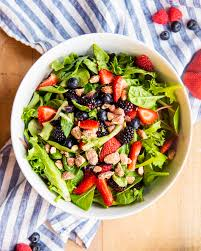

In [113]:
text_query = "give me salad recipe which looks like the given image"
image_query = load_image("sample\example_ingredients.jpg")
image_query

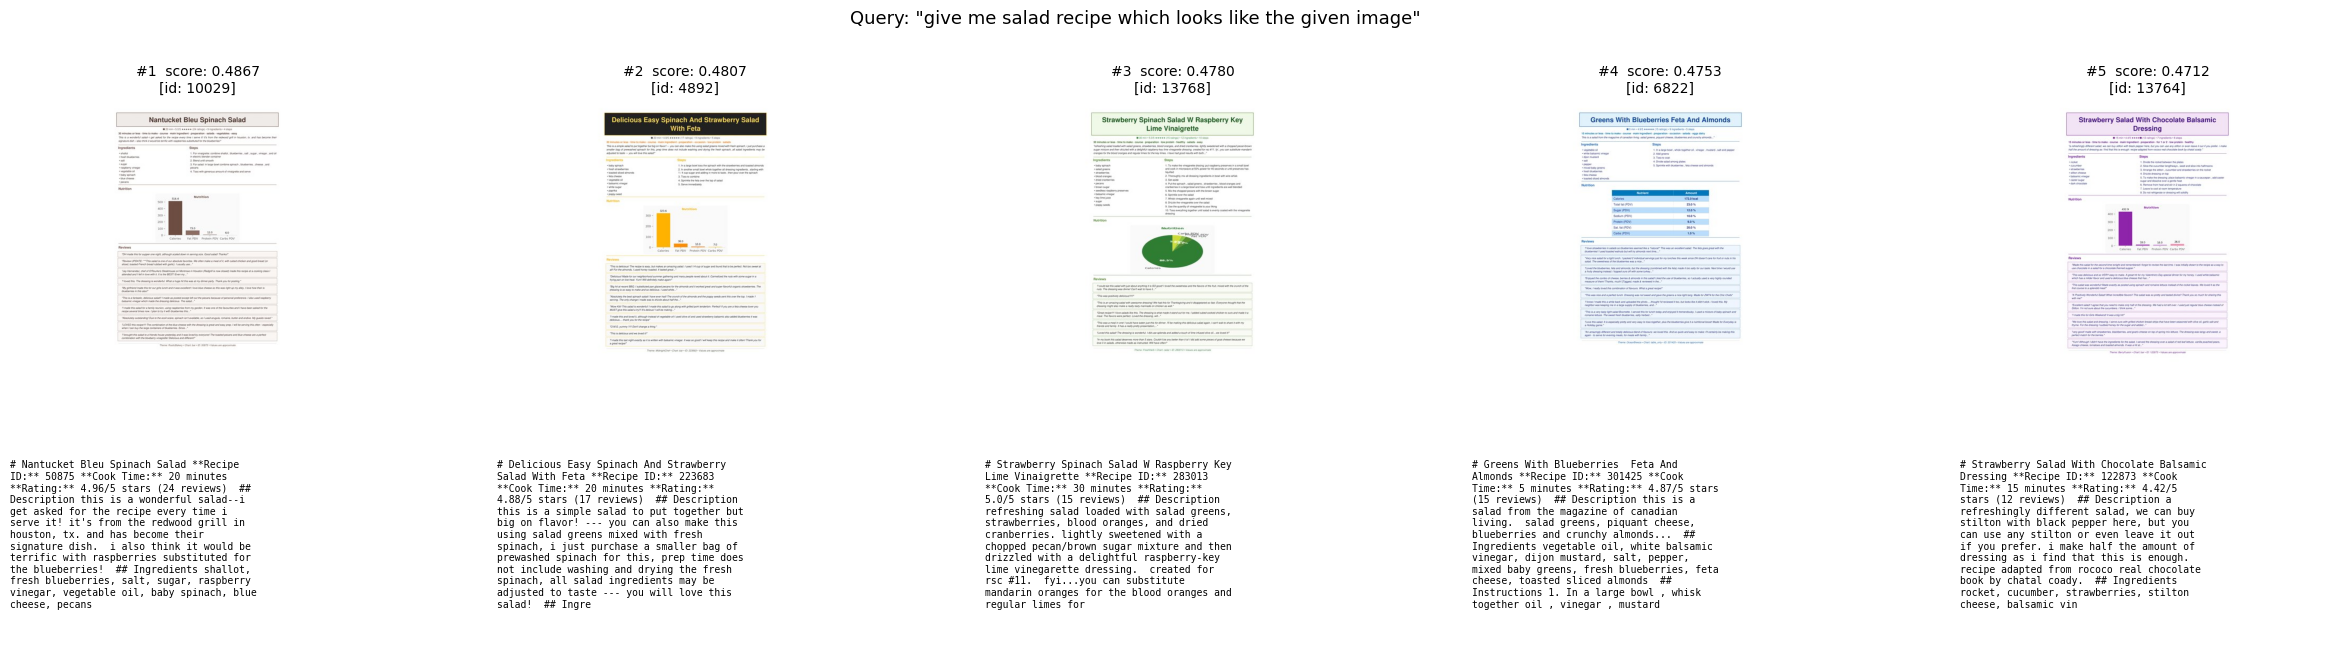

In [114]:
results = query_qdrant(
    text_query = text_query,
    image_query = image_query,
    top_k = 5
)
display_results(results, query_label = text_query)